## About dataset
diabetes _ binary _ health _ indicators _ BRFSS2015.csv is a clean dataset of 253,680 survey responses to the CDC's BRFSS2015. The target variable Diabetes_binary has 2 classes. 0 is for no diabetes, and 1 is for prediabetes or diabetes. This dataset has 21 feature variables and is not balanced.

---

## Important risk factors for diabetes :

( blood pressure (high) , cholesterol (high) , smoking , diabetes , obesity , age , sex , race , diet , exercise , alcohol consumption , BMI , Household Income , Marital Status , Sleep , Time since last checkup , Education , Health care coverage , Mental Health )

---
## About Columns :

Diabetes_binary : you have diabetes (0,1)

HighBP : Adults who have been told they have high blood pressure by a doctor, nurse, or other health professional (0,1)

HighChol : Have you EVER been told by a doctor, nurse or other health professional that your blood cholesterol is high? (0,1)

CholCheck : Cholesterol check within past five years (0,1)

BMI : Body Mass Index (BMI)

Smoker : Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] (0,1)

Stroke : (Ever told) you had a stroke. (0,1)

HeartDiseaseorAttack : Respondents that have ever reported having coronary heart disease (CHD) or myocardial infarction (MI) (0,1)

PhysActivity : Adults who reported doing physical activity or exercise during the past 30 days other than their regular job (0,1)

Fruits : Consume Fruit 1 or more times per day (0,1)

Veggies : Consume Vegetables 1 or more times per day (0,1)

HvyAlcoholConsump : Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week)(0,1)

AnyHealthcare : Do you have any kind of health care coverage, including health insurance, prepaid plans such as HMOs, or government plans such as Medicare, or Indian Health Service? (0,1)

NoDocbcCost : Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? (0,1)

GenHlth : Would you say that in general your health is: rate (1 ~ 5)

MentHlth : Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? (0 ~ 30)

PhysHlth : Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? (0 ~ 30)

DiffWalk : Do you have serious difficulty walking or climbing stairs? (0,1)

Sex : Indicate sex of respondent (0,1) (Female or Male)

Age : Fourteen-level age category (1 ~ 14)

Education : What is the highest grade or year of school you completed? (1 ~ 6)

Income : Is your annual household income from all sources: (If respondent refuses at any income level, code "Refused.") (1 ~ 8)

## Code

In [1]:
#data preprocessing n eval
import pandas as pd
import numpy as np
from imblearn.under_sampling import NearMiss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.pipeline import make_pipeline
# models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
#visualization
import matplotlib.pyplot as plt

# Load dataset
filepath = "dataset/diabetes_binary_health_indicators_BRFSS2015.csv"


In [2]:
df = pd.read_csv(filepath)
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
display(df['Diabetes_binary'].value_counts())

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

In [4]:
# imbalanced dataset
X = df.drop(columns='Diabetes_binary')
y = df['Diabetes_binary']


nm = NearMiss(version = 1 , n_neighbors = 10)
x_sm,y_sm= nm.fit_resample(X,y)

In [5]:
y_sm.shape , x_sm.shape

((70692,), (70692, 21))

In [6]:
y_sm.value_counts()

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

In [7]:
X_train , X_test , y_train , y_test = train_test_split(x_sm,y_sm, test_size=0.3 , random_state=42)

In [8]:
# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"), ),
    "Neural Net (MLP)": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=42)),
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Random Forest
              precision    recall  f1-score   support

         0.0       0.85      0.91      0.88     10601
         1.0       0.91      0.84      0.87     10607

    accuracy                           0.88     21208
   macro avg       0.88      0.88      0.88     21208
weighted avg       0.88      0.88      0.88     21208


XGBoost
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90     10601
         1.0       0.95      0.84      0.89     10607

    accuracy                           0.90     21208
   macro avg       0.90      0.90      0.90     21208
weighted avg       0.90      0.90      0.90     21208



d:\miniconda\envs\ml\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:44:07] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Logistic Regression
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89     10601
         1.0       0.92      0.83      0.87     10607

    accuracy                           0.88     21208
   macro avg       0.88      0.88      0.88     21208
weighted avg       0.88      0.88      0.88     21208



In [9]:
extra_models = {
    "K-Nearest Neighbors": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Naive Bayes": GaussianNB(),
}

for name, model in extra_models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(f"\n{name}")
  print(classification_report(y_test, y_pred))


K-Nearest Neighbors
              precision    recall  f1-score   support

         0.0       0.79      0.93      0.85     10601
         1.0       0.91      0.75      0.82     10607

    accuracy                           0.84     21208
   macro avg       0.85      0.84      0.84     21208
weighted avg       0.85      0.84      0.84     21208


Naive Bayes
              precision    recall  f1-score   support

         0.0       0.79      0.96      0.87     10601
         1.0       0.95      0.74      0.83     10607

    accuracy                           0.85     21208
   macro avg       0.87      0.85      0.85     21208
weighted avg       0.87      0.85      0.85     21208


Neural Net (MLP)
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90     10601
         1.0       0.94      0.85      0.89     10607

    accuracy                           0.90     21208
   macro avg       0.90      0.90      0.90     21208
weighted avg       0.9

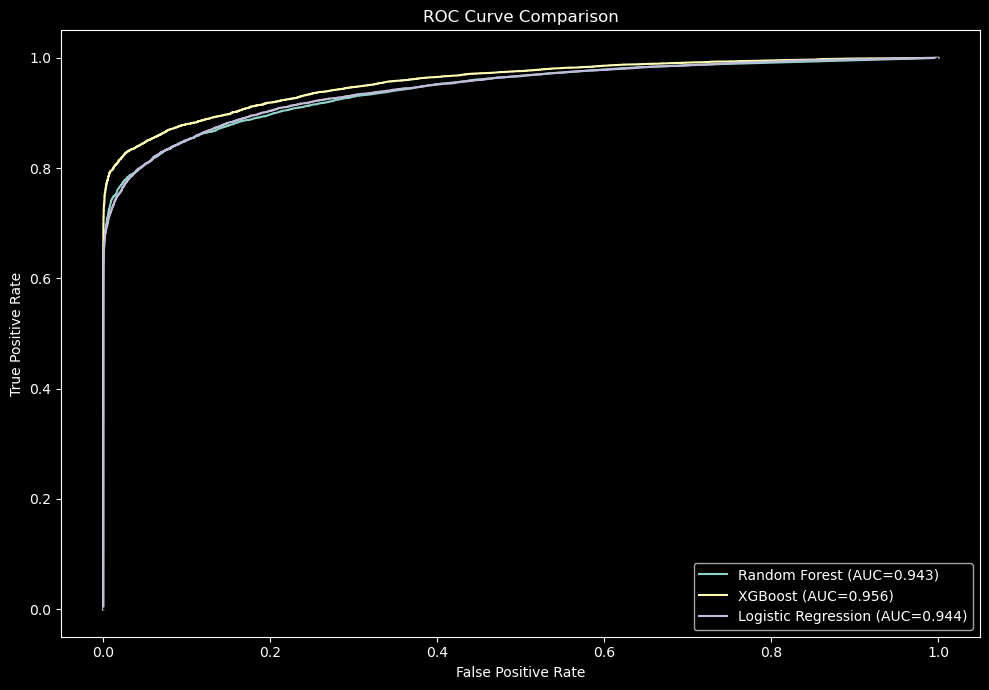

In [10]:


# 1. ROC AUC for all models
plt.figure(figsize=(10, 7))
model_auc = {}
for name, model in models.items():
    # Use probability or decision function for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    auc = roc_auc_score(y_test, y_score)
    model_auc[name] = auc
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# %% [markdown]
# ## Propensity Model Evaluation
# Evaluating the continuous risk scores (probabilities) generated by the models.

# %%
from sklearn.metrics import brier_score_loss, average_precision_score, roc_auc_score

print("=== Propensity Score Metrics ===")

# We will evaluate the main models dictionary 
# (Random Forest, XGBoost, Logistic Regression)
for name, model in models.items():
    # Ensure the model can output continuous probabilities
    if hasattr(model, "predict_proba"):
        # Extract the probability of class 1 (Diabetes)
        propensity_scores = model.predict_proba(X_test)[:, 1]
        
        # Calculate Propensity Metrics
        auc = roc_auc_score(y_test, propensity_scores)
        pr_auc = average_precision_score(y_test, propensity_scores)
        brier = brier_score_loss(y_test, propensity_scores)
        
        print(f"\n--- {name} ---")
        print(f"ROC-AUC:     {auc:.4f} ") # Ability to rank high vs low risk
        print(f"PR-AUC:      {pr_auc:.4f} ") # (Precision/Recall balance)
        print(f"Brier Score: {brier:.4f} ") #(Probability calibration error)
    else:
        print(f"\n--- {name} ---")
        print("Model does not support predict_proba() for propensity scoring.")

=== Propensity Score Metrics ===

--- Random Forest ---
ROC-AUC:     0.9426 
PR-AUC:      0.9554 
Brier Score: 0.0894 

--- XGBoost ---
ROC-AUC:     0.9562 
PR-AUC:      0.9664 
Brier Score: 0.0740 

--- Logistic Regression ---
ROC-AUC:     0.9437 
PR-AUC:      0.9564 
Brier Score: 0.0874 


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\n=== Sample Predictions vs Ground Truth ===")

# We will use XGBoost for this demonstration
target_model = models["XGBoost"]

# Extract continuous probabilities for the test set
probabilities = target_model.predict_proba(X_test)[:, 1]

# 1. Create a comparative DataFrame
results_df = pd.DataFrame({
    'Ground Truth': y_test,
    'Predicted Probability': np.round(probabilities, 2),
    'Predicted Class (>0.5)': (probabilities >= 0.5).astype(int)
})

# Merge with the original feature data to see the patient context
# We use X_test to show the specific features that led to the probability
comparison_df = pd.concat([X_test, results_df], axis=1)

# Display 10 random sample patients to see the side-by-side comparison
# We select a few specific readable columns for a cleaner terminal/notebook output
display_columns = ['BMI', 'HighBP', 'HighChol', 'Ground Truth', 'Predicted Probability', 'Predicted Class (>0.5)']
sample_output = comparison_df[display_columns].sample(10, random_state=42)
sample_output


=== Sample Predictions vs Ground Truth ===


,BMI,HighBP,HighChol,Ground Truth,Predicted Probability,Predicted Class (>0.5)
3826,27.0,0.0,1.0,0.0,0.02,0
59761,30.0,1.0,1.0,1.0,0.96,1
4584,33.0,1.0,0.0,0.0,0.13,0
7144,26.0,1.0,1.0,0.0,0.08,0
24211,24.0,0.0,0.0,0.0,0.01,0
27242,32.0,1.0,1.0,0.0,0.32,0
16231,31.0,0.0,0.0,0.0,0.07,0
53590,41.0,1.0,1.0,1.0,1.00,1
56883,29.0,1.0,0.0,1.0,0.44,0
43599,22.0,1.0,1.0,1.0,1.00,1
